# Estimating Spatially Varying Heat Transfer Coefficients Using Ensemble Smoothers (JAX)

This notebook is the JAX-accelerated version of the Ensemble Smoother example.
It uses `heat_equation_jax` from `dass.pde`, which is differentiable with respect to
the initial temperature field and the heat transfer coefficient field.
Ensemble runs are vectorized using `jax.vmap` instead of multiprocessing.

Imagine you're an archaeologist who has discovered a large, ancient metal plate buried in your garden.\
You're intrigued by its thermal properties, particularly how well it transfers heat, as this could provide clues about its composition and origin.\
Using a metal detector you've established the size and have concluded that it is too large to excavate without risking damage.\
Instead, you drill a few small holes at specific locations and measure the thermal conductivity ($k$) at these points.\
The sparse measurements show that the plates' thermal conductivity varies in space, but you need to know it everywhere.\
To gather more information, you decide to introduce a heat source by drilling a hole and lowering a heat element to warm up the plate at that point.\
After removing the heat source, the plate will cool down according to the heat equation from physics.\
Using the sparse measurements and the observed cooling behavior, your goal is to estimate the thermal conductivity everywhere on the plate.

We simplify by assuming the density and specific heat capacity ($\rho c$) are constant throughout the plate, allowing us to focus on estimating the spatially-varying thermal conductivity $k(x,y)$. This reduces the full heat equation:

$$\rho c \frac{\partial T}{\partial t} = \nabla \cdot (k \nabla T)$$

to the simplified form:

$$\frac{\partial T}{\partial t} = \nabla \cdot (k \nabla T)$$

In [1]:
import numpy as np
import pandas as pd
import jax
import jax.numpy as jnp

# Double precision: the KL terms and the C_M^-1 + Delta_Lambda Cholesky are
# numerically sensitive (prior covariance condition number ~1e6). Must be set
# before any jnp op.
jax.config.update("jax_enable_x64", True)
import iterative_ensemble_smoother as ies 

np.set_printoptions(suppress=True)
# Relatively easy to find good solution
rng = np.random.default_rng(1234)
# More difficult
# rng = np.random.default_rng(100)

import matplotlib.pyplot as plt

plt.rcParams["figure.figsize"] = (6, 6)
plt.rcParams.update({"font.size": 10})
# Ignore error when drawing many figures
plt.rcParams.update({"figure.max_open_warning": 0})
from ipywidgets import interact
import ipywidgets as widgets

In [2]:
%load_ext autoreload
%autoreload 2
from dass import pde, utils, analysis, taper, geostat

## Define ensemble size and parameters related to the simulator

In [3]:
# Defines how many simulations to run
N = 100 

# Number of grid-cells in x and y direction
nx = 10

# time steps
k_start = 0
k_end = 500

## Define and visualize the `prior` parameter ensemble

The Ensemble Smoother searches for solutions in `Ensemble Subspace`, which means that it tries to find a linear combination of the priors that best fit the observed data.
A good prior is therefore vital.

Since the prior depends on the random seed, some priors will lead to responses that are more difficult to work with than others.

In [4]:
def sample_prior_conductivity(N):
    mesh = np.meshgrid(np.linspace(0, 1, nx), np.linspace(0, 1, nx))
    return np.exp(geostat.gaussian_fields(mesh, rng, N, r=0.8))


# Evensens' formulation of the Ensemble Smoother has the prior as
# a (nx * nx, N) matrix, i.e (number of parameters, N).
A = sample_prior_conductivity(N).T

# We'll also need a list of matrices to run simulations in parallel later on.
# A list is also a bit easier to interactively visualize.
alphas = []
for j in range(N):
    alphas.append(A[:, j].reshape(nx, nx))

In [5]:
def interactive_prior_fields(n):
    fig, ax = plt.subplots()
    ax.set_title(f"Prior parameter field {n}")
    p = ax.pcolormesh(alphas[n].T)
    utils.colorbar(p)
    fig.tight_layout()


interact(
    interactive_prior_fields,
    n=widgets.IntSlider(min=0, max=N - 1, step=1, value=0),
)

interactive(children=(IntSlider(value=0, description='n', max=99), Output()), _dom_classes=('widget-interact',…

<function __main__.interactive_prior_fields(n)>

## Define true parameters, set true initial conditions and calculate the true temperature field

In real problems, these true parameter values are not known.
They are in fact what we are trying to estimate.
However, in this synthetic example we know everything which makes it much easier to judge whether an algorithm works or not.

In [6]:
# Set the coefficient of heat transfer for each grid cell.
# Let's use as true parameter field one realization from the prior
# to make it easier for the Ensemble Smoother to find the solution.
alpha_t = alphas[0]

# Resolution in the x-direction (nothing to worry about really)
dx = 1

# Calculate maximum `dt`.
# If higher values are used, the numerical solution will become unstable.
# Note that this could be avoided if we used an implicit solver.
dt = dx**2 / (4 * max(np.max(A), np.max(alpha_t)))

# Define initial condition, i.e., the initial temperature distribution.
# How you define initial conditions will effect the spread of results,
# i.e., how similar different realisations are.
u0 = np.zeros((nx, nx))
u0[5:7, 5:7] = 100

# How much noise to add to heat equation, also called model noise.
# scale = 0.1
scale = None
num_steps = k_end - k_start

# Convert to JAX arrays for the JAX forward model
u0_jax = jnp.array(u0)
alpha_t_jax = jnp.array(alpha_t)

u_t_jax = pde.heat_equation_jax(u0_jax, alpha_t_jax, dx, dt, num_steps)
u_t = np.asarray(u_t_jax)

## Plot every cells' heat transfer coefficient, i.e., the parameter field

Again, this is what we are trying estimate.

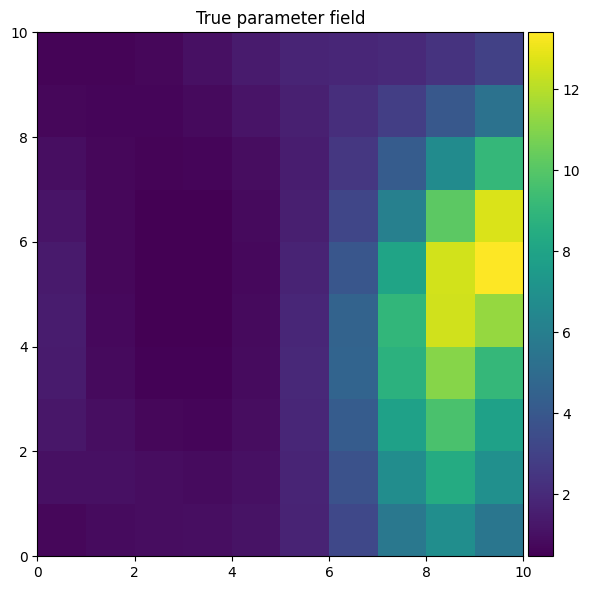

In [7]:
fig, ax = plt.subplots()
ax.set_title("True parameter field")
p = ax.pcolormesh(alpha_t.T)
utils.colorbar(p)
fig.tight_layout()

## Interactive plot of true temperature field

Shows how the temperature of the true field changes with time.

In [8]:
def interactive_truth(k):
    fig, ax = plt.subplots()
    fig.suptitle("True temperature field")
    p = ax.pcolormesh(u_t[k].T, cmap=plt.cm.jet, vmin=0, vmax=100)
    ax.set_title(f"k = {k}")
    utils.colorbar(p)
    fig.tight_layout()


interact(
    interactive_truth,
    k=widgets.IntSlider(min=k_start, max=k_end - 1, step=1, value=0),
)

interactive(children=(IntSlider(value=0, description='k', max=499), Output()), _dom_classes=('widget-interact'…

<function __main__.interactive_truth(k)>

## Define placement of sensors and generate synthetic observations based on the true temperature field

In [9]:
# We'll place the sensors close to heat-sources because the plate cools of quite quickly.
obs_coordinates = [
    utils.Coordinate(5, 3),
    utils.Coordinate(3, 5),
    utils.Coordinate(5, 7),
    utils.Coordinate(7, 5),
    utils.Coordinate(2, 2),
    utils.Coordinate(7, 2),
]

# At which times observations are taken
obs_times = np.linspace(5, k_end, 8, endpoint=False, dtype=int)

d = utils.observations(
    obs_coordinates,
    obs_times,
    u_t,
    lambda value: abs(0.05 * value),
    rng,
 )
m = d.shape[0]
print("Number of observations: ", m)

Number of observations:  48


# Plot temperature field at a specific time and show placement of sensors

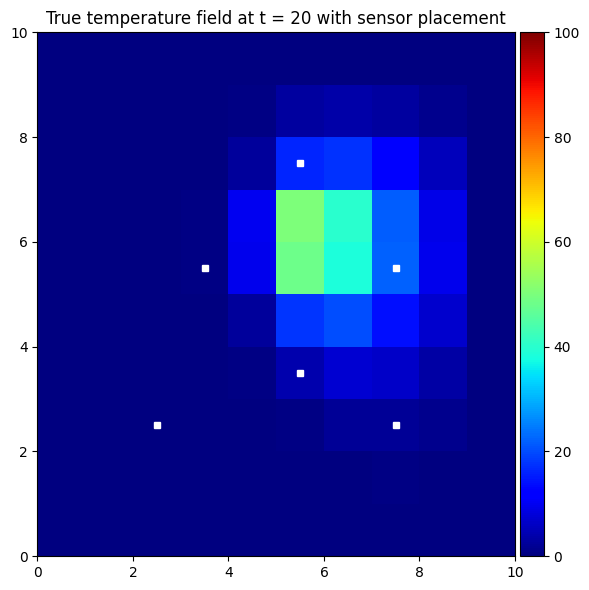

In [10]:
k_levels = d.index.get_level_values("k").to_list()
x_levels = d.index.get_level_values("x").to_list()
y_levels = d.index.get_level_values("y").to_list()

obs_coordinates_from_index = set(zip(x_levels, y_levels))
x, y = zip(*obs_coordinates_from_index)

fig, ax = plt.subplots()
time_to_plot_at = 20
p = ax.pcolormesh(u_t[time_to_plot_at].T, cmap=plt.cm.jet, vmin=0, vmax=100)
ax.set_title(f"True temperature field at t = {time_to_plot_at} with sensor placement")
utils.colorbar(p)
ax.plot([i + 0.5 for i in x], [j + 0.5 for j in y], "s", color="white", markersize=5)
fig.tight_layout()

# Running `N` simulations using `jax.vmap`

Instead of using multiprocessing (`p_map`), we use `jax.vmap` to vectorize the
forward model across the ensemble. This maps the heat equation over the batch of
parameter fields in a single vectorized call, leveraging JAX's XLA compiler for
efficient execution.

In [11]:
# Stack all prior parameter fields into a single JAX array of shape (N, nx, nx)
alphas_jax = jnp.stack([jnp.array(a) for a in alphas])

# Create JAX random keys for each ensemble member (used when scale is not None)
keys = jax.random.split(jax.random.PRNGKey(12345), N)

# Vectorize the heat equation over the alpha and key dimensions.
# in_axes: u0 (no batch), alpha (batch dim 0), dx (no), dt (no), num_steps (no), key (batch dim 0), scale (no)
batched_heat_equation = jax.vmap(
    pde.heat_equation_jax,
    in_axes=(None, 0, None, None, None, 0, None),
)

# Run all ensemble members at once
fwd_runs_jax = batched_heat_equation(u0_jax, alphas_jax, dx, dt, num_steps, keys, scale)
# Result shape: (N, num_steps + 1, nx, nx)

# Convert to list of numpy arrays (one per realization) for compatibility with plotting code
fwd_runs = [np.asarray(fwd_runs_jax[i]) for i in range(N)]

## Interactive plot of single realisations

Note that every realization has the same initial temperature field at time-step `k=0`, but that each realization cools down a bit differently because the plate in each realization has somewhat different material properties.

In [12]:
def interactive_realisations(k, n):
    fig, ax = plt.subplots()
    fig.suptitle(f"Temperature field for realisation {n}")
    p = ax.pcolormesh(fwd_runs[n][k].T, cmap=plt.cm.jet, vmin=0, vmax=100)
    ax.set_title(f"k = {k}")
    ax.plot(
        [i + 0.5 for i in x], [j + 0.5 for j in y], "s", color="white", markersize=5
    )
    utils.colorbar(p)
    fig.tight_layout()


interact(
    interactive_realisations,
    k=widgets.IntSlider(min=k_start, max=k_end - 1, step=1, value=0),
    n=widgets.IntSlider(min=0, max=N - 1, step=1, value=0),
)

interactive(children=(IntSlider(value=0, description='k', max=499), IntSlider(value=0, description='n', max=99…

<function __main__.interactive_realisations(k, n)>

# Ensemble Smoother (ES)

## Measure model response at points in time and space where we have observations

The `Ensemble Smoother` uses the difference between what the simulator claims happened at `(k, x, y)` and what uncertain sensors claim happened at the same point in time and space.
Hence, we only need the responses where we have actual observations.

In [13]:
Y_df = pd.DataFrame({"k": k_levels, "x": x_levels, "y": y_levels})

for real, fwd_run in enumerate(fwd_runs):
    Y_df = Y_df.assign(**{f"R{real}": fwd_run[k_levels, x_levels, y_levels]})

Y_df = Y_df.set_index(["k", "x", "y"])
assert Y_df.index.is_unique

Y = Y_df.values

assert Y.shape == (
    m,
    N,
), "Measured responses must be a matrix with dimensions (number of observations x number of realisations)"

/var/folders/qj/kll_f5_n7cl8w2l46ndtgws00000gp/T/ipykernel_80550/3622422186.py:4: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  Y_df = Y_df.assign(**{f"R{real}": fwd_run[k_levels, x_levels, y_levels]})


## Checking `Coverage`

Ideally, we want our model to be so good that its responses do not deviate much from what our sensors are telling us.
When this is the case, we say that we have achieved good `coverage`.

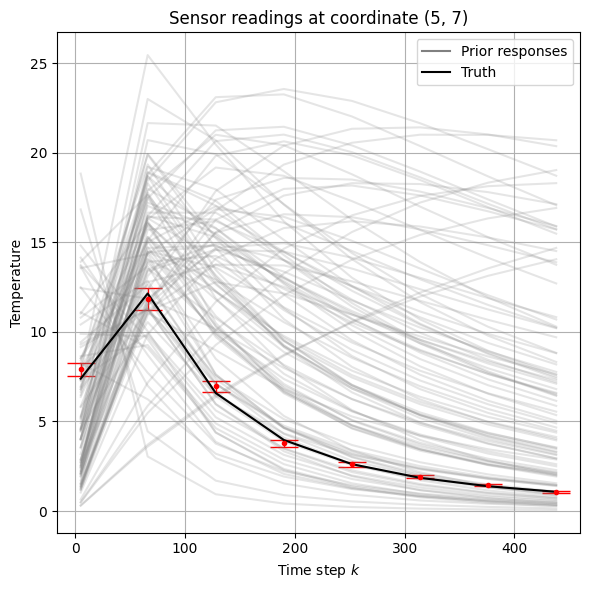

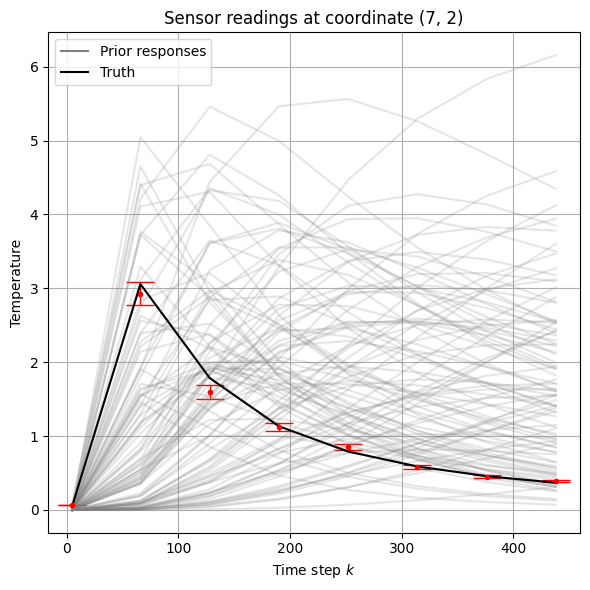

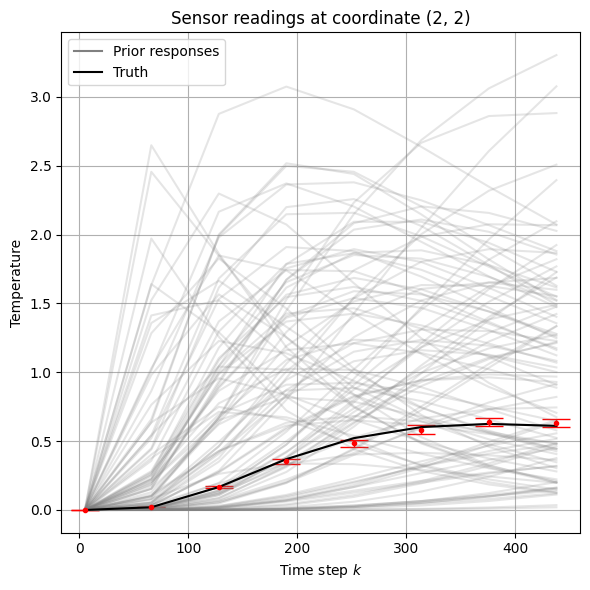

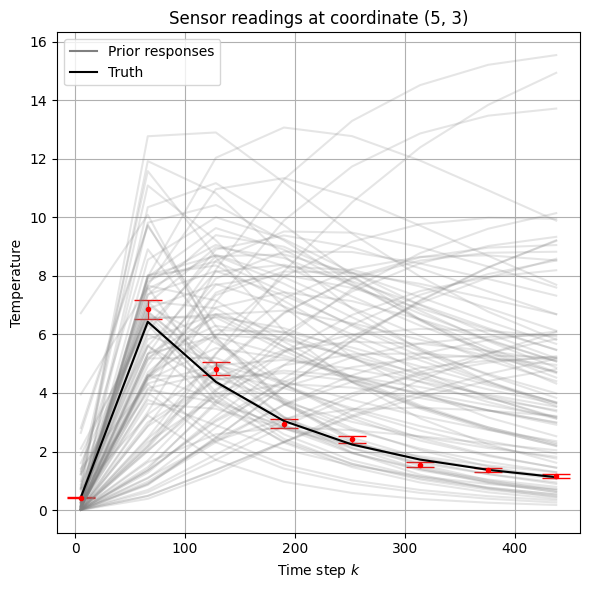

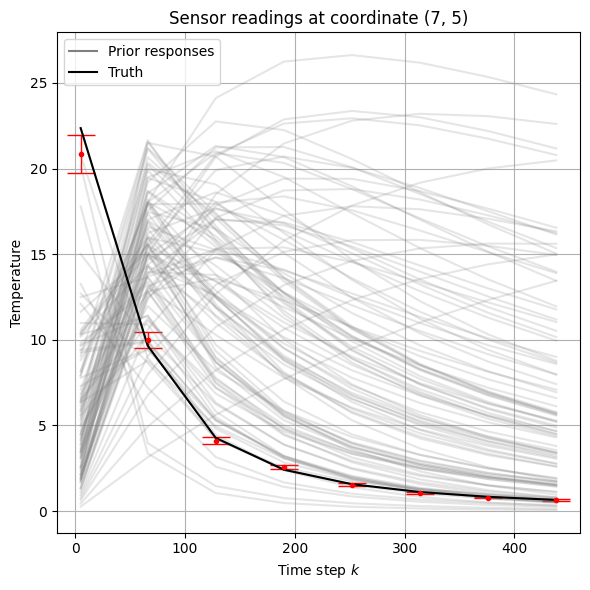

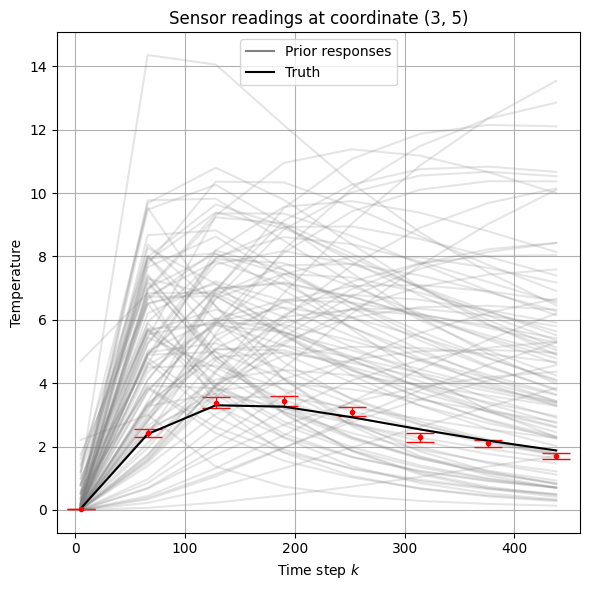

In [14]:
utils.plot_responses(np.unique(k_levels), d, Y_df, u_t)

## Deactivate sensors that measure the same temperature in all realizations

This means that the temperature did not change at that sensor location.
Including these will lead to numerical issues.

In [15]:
enough_ens_var_idx = Y.var(axis=1) > 1e-6

print(
    f"{list(enough_ens_var_idx).count(False)} measurements will be deactivated because of ensemble collapse"
)
Y = Y[enough_ens_var_idx, :]


1 measurements will be deactivated because of ensemble collapse


## Deactivate responses that are too far away from observations

In [16]:
ens_std = Y.std(axis=1)
ens_mean = Y.mean(axis=1)
obs_std = d.sd.values[enough_ens_var_idx]
obs_value = d.value.values[enough_ens_var_idx]
innov = obs_value - ens_mean

is_outlier = np.abs(innov) > 3.0 * (ens_std + obs_std)

print(
    f"{list(is_outlier).count(True)} out of {Y.shape[0]} measurements will be deactivated because they are outliers"
)
Y = Y[~is_outlier, :]


1 out of 47 measurements will be deactivated because they are outliers


## Perform ES update

In [17]:
smoother = ies.ESMDA(covariance=obs_std[~is_outlier] ** 2, observations=obs_value[~is_outlier], alpha=1, seed=rng)

In [18]:
A_ES = smoother.assimilate(A, Y, overwrite=False)

In [19]:
# The update may give non-physical parameter values, which here means negative heat conductivity.
# Setting negative values to a small positive value but not zero because we want to be able to divide by them.
A_ES = A_ES.clip(min=1e-8)

## Numerical comparison of prior and posterior using RMSE

The posterior calculated by ES is on average expected to be closer to the truth than the prior.
By "closer", we mean in terms of Root Mean Squared Error (RMSE).
The reason for this is that ES is based on the Kalman Filter, which is the "Best Linear Unbiased Estimator" (BLUE) and BLUE estimators have this property.
However, this holds for certain only when the number of realizations tends to infinity.
In practice this mean that we might end up with an increased RMSE when using a finite number of realizations.

In [20]:
err_posterior = alpha_t.ravel() - A_ES.mean(axis=1)
np.sqrt(np.mean(err_posterior * err_posterior))

np.float64(1.896369788823733)

In [21]:
err_prior = alpha_t.ravel() - A.mean(axis=1)
np.sqrt(np.mean(err_prior * err_prior))

np.float64(3.8267657272796898)

# Physically Structured Variational Inference (PSVI)

Instead of using the Ensemble Smoother, we can leverage JAX's automatic differentiation to perform gradient-based variational inference directly through the physics model.

**Note on fairness**: In this notebook, the true conductivity field is set to `alphas[0]` — the first member of the prior ensemble. Since ES searches for linear combinations of ensemble members, the truth is exactly representable in its search space, giving it an inherent advantage in parameter-space RMSE. PSVI searches freely in $\mathbf{m}$-space without this constraint. In a real-world scenario where the truth is *not* a prior ensemble member, ES would not have this edge.

The goal is to find an optimal distribution $q(\mathbf{m})$ that minimizes the Kullback-Leibler (KL) divergence between $q(\mathbf{m})$ and the target posterior pdf $p(\mathbf{m} \mid \mathbf{d}_{obs})$:

$$KL(q(\mathbf{m}) \| p(\mathbf{m} \mid \mathbf{d}_{obs})) = E_q[\log q(\mathbf{m})] - E_q[\log p(\mathbf{m} \mid \mathbf{d}_{obs})]$$

Substituting Bayes' theorem gives

$$KL(q(\mathbf{m}) \| p(\mathbf{m} \mid \mathbf{d}_{obs})) = E_q[\log q(\mathbf{m})] - E_q\left[\log \frac{p(\mathbf{d}_{obs} \mid \mathbf{m}) p(\mathbf{m})}{p(\mathbf{d}_{obs})}\right]$$

Using the joint density $p(\mathbf{m}, \mathbf{d}_{obs}) = p(\mathbf{d}_{obs} \mid \mathbf{m}) p(\mathbf{m})$, we get

$$KL(q(\mathbf{m}) \| p(\mathbf{m} \mid \mathbf{d}_{obs})) = E_q[\log q(\mathbf{m})] - E_q[\log p(\mathbf{m}, \mathbf{d}_{obs})] + \log p(\mathbf{d}_{obs})$$

Notice that $\log p(\mathbf{d}_{obs})$ is constant, so minimizing the KL divergence is equivalent to maximizing the Evidence Lower Bound (ELBO):

$$\begin{aligned}\text{ELBO} &= \log p(\mathbf{d}_{\text{obs}}) - \text{KL}\bigl(q(\mathbf{m}) \| p(\mathbf{m} \mid \mathbf{d}_{\text{obs}})\bigr) \\&= E_q[\log p(\mathbf{m}, \mathbf{d}_{\text{obs}})] - E_q[\log q(\mathbf{m})] \\&= E_q[\log p(\mathbf{d}_{\text{obs}} \mid \mathbf{m})] + E_q[\log p(\mathbf{m})] - E_q[\log q(\mathbf{m})] \\&= E_q[\log p(\mathbf{d}_{\text{obs}} \mid \mathbf{m})] - \text{KL}\bigl(q(\mathbf{m}) \| p(\mathbf{m})\bigr)\end{aligned}$$

The last line is the form implemented below: the code estimates $E_q[\log p(\mathbf{d}_{obs} \mid \mathbf{m})]$ with Monte Carlo samples from $q(\mathbf{m})$, computes $\text{KL}(q(\mathbf{m}) \| p(\mathbf{m}))$ in closed form for Gaussians, and minimizes the negative ELBO, i.e. $-(\text{expected log-likelihood} - \text{KL})$.

The ELBO is computationally tractable because it avoids direct evaluation of the high-dimensional evidence $p(\mathbf{d}_{obs})$ and serves as the objective function in most variational inference methods.

where:
- $p(\mathbf{d}_{\text{obs}} \mid \mathbf{m})$ is the Gaussian likelihood comparing observations to forward model predictions
- $p(\mathbf{m}) = \mathcal{N}(0, C_M)$ is the Gaussian prior from the geostatistical model
- $q(\mathbf{m}) = \mathcal{N}(\mathbf{\mu}_q, \mathbf{L} \mathbf{L}^\top)$ is the variational family we choose to approximate the posterior, where $\mathbf{L}$ is a sparse lower-triangular Cholesky factor. Writing the covariance as $\mathbf{L} \mathbf{L}^\top$ guarantees that it is valid, and the sparsity pattern in $\mathbf{L}$ is determined by a grid neighborhood structure: only cells within Chebyshev radius `nb_radius` of each other get a non-zero entry in $\mathbf{L}$.
A Gaussian is a common choice because it makes the variational objective tractable: samples can be generated with the reparameterization trick, $\log q(\mathbf{m})$ is available in closed form and gradients with respect to $\mu_q$ and $\mathbf{L}$ are straightforward.

The reparameterization trick is to instead of sampling $\mathbf{m}$ directly from $q(\mathbf{m}) = \mathcal{N}(\mathbf{\mu}_q, \mathbf{L} \mathbf{L}^\top)$, we write

$$\mathbf{\epsilon} \sim \mathcal{N}(\mathbf{0}, \mathbf{I}), \mathbf{m} = \mathbf{\mu}_q + \mathbf{L}\mathbf{\epsilon}$$

This is equivalent, because if $\mathbf{\epsilon}$ is standard normal, then $\mathbf{\mu}_q + \mathbf{L}\mathbf{\epsilon}$ has mean $\mathbf{\mu}_q$ and covariance $\mathbf{L}\mathbf{L}^\top$.
So, the reparameterization trick turns stochastic sampling from the variational distribution into a differentiable deterministic map applied to simple noise.

The sparsity constraint in this PSVI variant is imposed on the Cholesky factor $\mathbf{L}$, not directly on $\Sigma_q$. Because $\Sigma_q = \mathbf{L}\mathbf{L}^\top$, a banded $\mathbf{L}$ induces a banded covariance matrix $\Sigma_q$ with the same bandwidth. However, the product $\mathbf{L}\mathbf{L}^\top$ generally fills in additional entries within that band, so $\Sigma_q$ is usually less sparse than $\mathbf{L}$ even though it remains banded.

In this notebook, the allowed nonzero offsets in $\mathbf{L}$ are $0$, $1$, $nx-1$, $nx$, and $nx+1$. Therefore the resulting covariance $\Sigma_q$ is also banded, with bandwidth at most $nx+1$, but it does not preserve the exact same five-diagonal sparsity pattern as $\mathbf{L}$.

For the KL term, the implementation uses the closed-form divergence between two multivariate Gaussians. If

$$q(\mathbf{m}) = \mathcal{N}(\mu, \Sigma_q), \qquad p(\mathbf{m}) = \mathcal{N}(0, C_M),$$

then

$$\mathrm{KL}(q \| p) = \frac{1}{2}\left[\mathrm{tr}(C_M^{-1} \Sigma_q) + \mu^\top C_M^{-1} \mu - d + \log |C_M| - \log |\Sigma_q|\right].$$

In this notebook, $\Sigma_q = \mathbf{L}\mathbf{L}^\top$, so the terms in the code map directly to this formula:

- $\mathrm{tr}(C_M^{-1} \Sigma_q)$ becomes `jnp.sum(prior_prec * Sigma_q)`
- $\mu^\top C_M^{-1} \mu$ becomes `mu @ prior_prec @ mu` because the prior mean is zero
- $d$ becomes `d_param`
- $\log |C_M|$ becomes `prior_logdet`
- $\log |\Sigma_q|$ becomes `log_det_q`

The log-determinant of $\Sigma_q$ is computed from the Cholesky factor because

$$|\Sigma_q| = |\mathbf{L}\mathbf{L}^\top| = |\mathbf{L}|^2, \qquad \log |\Sigma_q| = 2 \sum_i \log L_{ii}.$$

Derivation follows section 2.1 of [Zhang et al. (2026)](https://arxiv.org/abs/2602.02993).

## Set up prior covariance and define ELBO

In [22]:
import optax

# Prior covariance C_M in m-space (matching the geostatistical prior used for ensemble generation)
mesh_prior = np.meshgrid(np.linspace(0, 1, nx), np.linspace(0, 1, nx))
pts = geostat.vectorize(*mesh_prior)
dists = geostat.dist_euclid(pts)

# Convert the unit-sill Gaussian semivariogram to a prior covariance matrix
# (covariance = sill - semivariogram here, with sill normalized to 1),
# then add a small diagonal jitter to keep the matrix numerically positive definite.
prior_cov = 1 - geostat.variogram_gauss(dists, r=0.8) + 1e-5 * np.eye(len(dists))

# Use Cholesky-based solve instead of explicit matrix inverse for better numerical stability
prior_cov_chol = jnp.linalg.cholesky(jnp.array(prior_cov))
prior_prec = jax.scipy.linalg.cho_solve((prior_cov_chol, True), jnp.eye(len(dists)))
prior_logdet = float(np.linalg.slogdet(prior_cov)[1])

d_param = nx * nx
diag_idx = jnp.arange(d_param)
tri_diag_eps = 1e-8

# For first neighbors (Chebyshev distance 1) on an nx×nx grid, the lower-triangular
# entries of L lie on exactly 5 sub-diagonals at offsets 0, 1, nx-1, nx, nx+1.
# Boolean masks zero out entries that would cross grid-row boundaries.
band_offsets = [0, 1, nx - 1, nx, nx + 1]
band_masks = {}
for b in band_offsets:
    n = d_param - b
    rows, cols = jnp.arange(b, b + n), jnp.arange(n)
    band_masks[b] = (jnp.abs(rows // nx - cols // nx) <= 1) & \
                     (jnp.abs(rows % nx - cols % nx) <= 1)

n_tril = sum(int(m.sum()) for m in band_masks.values())
n_tril_full = d_param * (d_param + 1) // 2
print(f"Sparse Cholesky (nb_radius=1): {n_tril} parameters "
      f"(vs {n_tril_full} for full-rank, {100 * n_tril / n_tril_full:.1f}% of full)")

# Use exactly the same data points as ES (filtered for low prior ensemble variance and outliers)
valid_idx = np.copy(enough_ens_var_idx)
valid_idx[valid_idx] = ~is_outlier
d_filtered = d.iloc[valid_idx]

obs_k_vi = jnp.array(d_filtered.index.get_level_values("k").to_list(), dtype=jnp.int32)
obs_x_vi = jnp.array(d_filtered.index.get_level_values("x").to_list(), dtype=jnp.int32)
obs_y_vi = jnp.array(d_filtered.index.get_level_values("y").to_list(), dtype=jnp.int32)
obs_val_vi = jnp.array(d_filtered["value"].values)
# Floor variances to avoid divide-by-zero and ill-conditioned likelihood weights
obs_var_vi = jnp.maximum(jnp.array(d_filtered["sd"].values) ** 2, 1e-12)

# Maximum stable alpha for the explicit scheme: alpha_max = dx^2 / (4 * dt)
alpha_max = float(dx**2 / (4 * dt))

n_mc = 4  # Monte Carlo samples per gradient step


def _build_L(params):
    """Build L from 5 sub-diagonal bands for nearest-neighbor structure."""
    L = jnp.diag(jax.nn.softplus(params["band_0"]) + tri_diag_eps)
    for b in [1, nx - 1, nx, nx + 1]:
        L = L + jnp.diag(params[f"band_{b}"] * band_masks[b], -b)
    return L


def neg_elbo(params, key, beta):
    """Negative ELBO: -(E_q[log p(d_obs | m)] - KL(q(m) || p(m)))."""
    mu = params["mu"]
    L = _build_L(params)

    key_eps, key_model = jax.random.split(key)

    # Reparameterization: sample m ~ N(mu, L L^T)
    eps = jax.random.normal(key_eps, shape=(n_mc, d_param))
    log_alpha = mu[None, :] + (L @ eps.T).T
    # Clamp alpha = exp(m) to ensure numerical stability of the explicit PDE solver
    alpha_samples = jnp.clip(jnp.exp(log_alpha), 1e-8, alpha_max).reshape(n_mc, nx, nx)

    # Forward model g(m) for all MC samples
    mc_keys = jax.random.split(key_model, n_mc)
    u_mc = jax.vmap(
        pde.heat_equation_jax,
        in_axes=(None, 0, None, None, None, 0, None),
    )(u0_jax, alpha_samples, dx, dt, num_steps, mc_keys, None)

    # Responses at observation points: g(m) evaluated at sensor locations
    responses = u_mc[:, obs_k_vi, obs_x_vi, obs_y_vi]

    # E_q[log p(d_obs | m)] — diagonal Gaussian observation noise
    residuals = obs_val_vi[None, :] - responses
    log_lik = -0.5 * jnp.sum(
        residuals**2 / obs_var_vi[None, :] + jnp.log(2.0 * jnp.pi * obs_var_vi)[None, :],
        axis=1,
    )
    expected_log_lik = jnp.mean(log_lik)

    # KL(q(m) || p(m)) for q = N(mu, Sigma_q), p = N(0, C_M)
    # = 0.5 * [tr(C_M^{-1} Sigma_q) + mu^T C_M^{-1} mu - d + log|C_M| - log|Sigma_q|]
    Sigma_q = L @ L.T
    log_det_q = 2.0 * jnp.sum(jnp.log(jnp.maximum(L[diag_idx, diag_idx], tri_diag_eps)))
    kl = 0.5 * (
        jnp.sum(prior_prec * Sigma_q)      # tr(C_M^{-1} Sigma_q): covariance mismatch against the prior
        + mu @ prior_prec @ mu            # mu^T C_M^{-1} mu: mean mismatch because the prior mean is zero
        - d_param                         # -d: normalization term from the closed-form Gaussian KL
        + prior_logdet                    # +log|C_M|: prior covariance volume term
        - log_det_q                       # -log|Sigma_q|: variational covariance volume term
    )

    return -(expected_log_lik - beta * kl)

Sparse Cholesky (nb_radius=1): 442 parameters (vs 5050 for full-rank, 8.8% of full)


## Run variational optimization

For a like-for-like forward-model budget comparison with ES, we keep `n_mc = 1` and set the number of VI iterations equal to the ensemble size `N`.
That means changing `N` automatically changes the number of PSVI optimization steps as well.

We also scale the learning-rate schedule with `N`: the warmup lasts for about 10% of the run and the exponential decay transition spans about 40% of the run. This keeps the optimizer behavior roughly comparable when you rerun the notebook with a different ensemble size.

The first iteration is slow due to JIT compilation. Subsequent iterations are fast.

In [23]:
# vi_params stores the trainable parameters of q(m) = N(mu, L L^T).
# mu is the variational mean in log-conductivity space; band_0 the (softplus) diagonal
# of L; band_{1,nx-1,nx,nx+1} the neighbour off-diagonals (mean-field init at zero).
vi_params = {
    "mu": jnp.zeros(d_param),
    "band_0": jnp.full(d_param, -1.0),  # softplus(-1) ~ 0.31
    **{f"band_{b}": jnp.zeros(d_param - b) for b in [1, nx - 1, nx, nx + 1]},
}

# Training budget (shared with the precision run for a fair comparison).
# KL annealing lets the likelihood pull q off the prior during warmup before the KL
# term (which otherwise dominates with few observations) clamps it back.
n_vi_iters = 1200
kl_warmup = 300
warmup_steps = max(1, int(round(0.1 * n_vi_iters)))
transition_steps = max(1, int(round(0.4 * n_vi_iters)))
schedule = optax.warmup_exponential_decay_schedule(
    init_value=1e-4,
    peak_value=0.05,
    warmup_steps=warmup_steps,
    decay_rate=0.7,
    transition_steps=transition_steps,
    end_value=1e-3,
)
optimizer = optax.chain(
    optax.clip_by_global_norm(1.0),
    optax.adam(learning_rate=schedule),
)
opt_state = optimizer.init(vi_params)


@jax.jit
def vi_step(params, opt_state, key, beta):
    loss, grads = jax.value_and_grad(neg_elbo)(params, key, beta)
    updates, new_opt_state = optimizer.update(grads, opt_state, params)
    new_params = optax.apply_updates(params, updates)
    return new_params, new_opt_state, loss


vi_key = jax.random.PRNGKey(42)
vi_losses = []

print(
    f"Starting PSVI optimization: n_vi_iters={n_vi_iters}, n_mc={n_mc}, "
    f"kl_warmup={kl_warmup} (first iteration includes JIT compilation)..."
)
for i in range(n_vi_iters):
    vi_key, subkey = jax.random.split(vi_key)
    beta = jnp.minimum(1.0, (i + 1) / kl_warmup)
    vi_params, opt_state, loss = vi_step(vi_params, opt_state, subkey, beta)
    loss_float = float(loss)
    if not np.isfinite(loss_float):
        raise FloatingPointError(f"Non-finite neg-ELBO at iteration {i}: {loss_float}")
    vi_losses.append(loss_float)

    if i % 100 == 0:
        print(f"  Iteration {i:4d}: (annealed) neg-ELBO = {loss_float:.2f}")

print("Done.")
print(f"  Iteration {n_vi_iters:4d}: neg-ELBO = {vi_losses[-1]:.2f}")

Starting PSVI optimization: n_vi_iters=1200, n_mc=4, kl_warmup=300 (first iteration includes JIT compilation)...


W0709 07:32:56.486640  813273 cpp_gen_intrinsics.cc:74] Empty bitcode string provided for eigen. Optimizations relying on this IR will be disabled.


  Iteration    0: (annealed) neg-ELBO = 49180.00


  Iteration  100: (annealed) neg-ELBO = 1127.29
  Iteration  200: (annealed) neg-ELBO = 247.13


  Iteration  300: (annealed) neg-ELBO = 191.93
  Iteration  400: (annealed) neg-ELBO = 137.23


  Iteration  500: (annealed) neg-ELBO = 122.98
  Iteration  600: (annealed) neg-ELBO = 111.70


  Iteration  700: (annealed) neg-ELBO = 103.18
  Iteration  800: (annealed) neg-ELBO = 103.64


  Iteration  900: (annealed) neg-ELBO = 91.56
  Iteration 1000: (annealed) neg-ELBO = 88.94


  Iteration 1100: (annealed) neg-ELBO = 80.43
Done.
  Iteration 1200: neg-ELBO = 78.52


## Extract PSVI posterior samples

In [24]:
# Generate N samples from PSVI posterior (matching ensemble size for fair comparison)
vi_key, sample_key = jax.random.split(vi_key)
mu_post = vi_params["mu"]
L_post = _build_L(vi_params)

eps_post = jax.random.normal(sample_key, shape=(N, d_param))
log_alpha_post = mu_post[None, :] + (L_post @ eps_post.T).T
# Apply the same numerical stability bounds used during optimization
A_PSVI = np.array(jnp.clip(jnp.exp(log_alpha_post), 1e-8, alpha_max).T)  # (d_param, N)

err_psvi = alpha_t.ravel() - A_PSVI.mean(axis=1)
rmse_psvi = np.sqrt(np.mean(err_psvi**2))
print(f"RMSE PSVI: {rmse_psvi:.6f}")

# Run forward model on PSVI posterior samples
alphas_psvi = [A_PSVI[:, j].reshape(nx, nx) for j in range(N)]
alphas_psvi_jax = jnp.stack([jnp.array(a) for a in alphas_psvi])
fwd_runs_psvi_jax = batched_heat_equation(
    u0_jax, alphas_psvi_jax, dx, dt, num_steps, keys, scale
)

Y_df_psvi = pd.DataFrame({"k": k_levels, "x": x_levels, "y": y_levels})
for real in range(N):
    fwd_run = np.asarray(fwd_runs_psvi_jax[real])
    Y_df_psvi = Y_df_psvi.assign(
        **{f"R{real}": fwd_run[k_levels, x_levels, y_levels]}
    )
Y_df_psvi = Y_df_psvi.set_index(["k", "x", "y"])

RMSE PSVI: 3.071260


/var/folders/qj/kll_f5_n7cl8w2l46ndtgws00000gp/T/ipykernel_80550/2262844303.py:25: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  Y_df_psvi = Y_df_psvi.assign(


# PSVI with a Prior-Anchored Sparse Precision Matrix Parameterization

> This section is more precise if read as a **Gaussian variational approximation parameterized by a sparse precision matrix on a local grid graph**. The term GMRF is appropriate because zeros in the precision matrix encode conditional independences, but the implementation below is still a dense JAX implementation at this problem size: it builds `Lambda_q` explicitly, factors it with a dense Cholesky, and computes `Lambda_q^{-1}` exactly inside the KL term.

Instead of parameterizing $q(\mathbf{m})$ through a covariance Cholesky factor $\Sigma_q = LL^\top$, we parameterize it as

$$q(\mathbf{m}) = \mathcal{N}(\mu_q, \Lambda_q^{-1}),$$

where $\Lambda_q$ is a symmetric positive-definite precision matrix. In this prior-anchored version, the variational precision is

$$\Lambda_q = C_M^{-1} + \Delta\Lambda_q,$$

where $C_M^{-1}$ is the prior precision and $\Delta\Lambda_q$ is a learned sparse positive-definite precision update. This mirrors the linear-Gaussian posterior structure $\Lambda_{post} = C_M^{-1} + J^\top R^{-1}J$ and prevents the variational distribution from learning a covariance that is badly misaligned with the prior.

## What is sparse here?

The sparsity constraint is imposed on the learned update $\Delta\Lambda_q$, not on its Cholesky factor. In the code, the allowed off-diagonal entries lie on the four grid-neighbor offsets

$$1,\; nx-1,\; nx,\; nx+1,$$

with row-boundary masks reused from the covariance parameterization. This gives a local grid graph for the data-induced precision update. The total precision $\Lambda_q$ is generally dense here because the Gaussian prior precision $C_M^{-1}$ is dense.

If the prior precision were sparse, zeros in the total precision would encode conditional independence. With the dense geostatistical prior used here, the sparse object should instead be interpreted as a sparse correction to the prior precision.

## How positive definiteness is enforced in the implementation

The implementation does not optimize an arbitrary sparse symmetric update. Instead it constructs

$$\Delta\Lambda_q = D + S,$$

where $S$ contains the learned symmetric off-diagonal neighbor couplings and the diagonal matrix $D$ is chosen large enough to make $\Delta\Lambda_q$ strictly diagonally dominant. Concretely, the code sets

$$D_{ii} = \operatorname{softplus}(d_i) + \sum_{j \ne i} |S_{ij}| + \varepsilon,$$

which guarantees that $\Delta\Lambda_q$ is symmetric positive definite. Since $C_M^{-1}$ is also positive definite, $\Lambda_q = C_M^{-1} + \Delta\Lambda_q$ is positive definite. This is exactly what `_build_precision(params)` implements.

## How sampling maps to `neg_elbo_prec`

Inside `neg_elbo_prec`, the variational sample is generated as follows:

1. Build `Lambda_q = _build_precision(params)`.
2. Compute its Cholesky factor `chol_prec` such that $\Lambda_q = L_\Lambda L_\Lambda^\top$.
3. Draw $\epsilon \sim \mathcal{N}(0, I)$.
4. Solve

$$L_\Lambda^\top \mathbf{z} = \epsilon,$$

so that $\mathbf{z} \sim \mathcal{N}(0, \Lambda_q^{-1})$.
5. Set

$$\mathbf{m} = \mu_q + \mathbf{z}.$$

This is why the code uses `solve_triangular(chol_prec.T, eps.T, lower=False)` rather than multiplying by a covariance factor.

## How the negative ELBO maps to `neg_elbo_prec`

The optimized objective is

$$-\mathrm{ELBO} = -\left(\mathbb{E}_q[\log p(\mathbf{d}_{obs} \mid \mathbf{m})] - \mathrm{KL}(q(\mathbf{m})\|p(\mathbf{m}))\right).$$

The code computes this in three blocks:

1. **Sample from $q$** using the precision-based reparameterization above.
2. **Estimate the expected log-likelihood** with `n_mc_prec = 1` Monte Carlo sample and the JAX heat-equation solver evaluated only at the filtered observation points.
3. **Compute the Gaussian KL term** using the closed form

$$\mathrm{KL}(q\|p) = \frac{1}{2}\left[\mathrm{tr}(C_M^{-1}\Sigma_q) + \mu_q^\top C_M^{-1}\mu_q - d + \log|C_M| + \log|\Lambda_q|\right],$$

where $\Sigma_q = \Lambda_q^{-1}$. In the implementation:

- `Sigma_q = cho_solve((chol_prec, True), I)` computes $\Lambda_q^{-1}$.
- `jnp.sum(prior_prec * Sigma_q)` computes $\mathrm{tr}(C_M^{-1}\Sigma_q)$.
- `mu @ prior_prec @ mu` computes $\mu_q^\top C_M^{-1}\mu_q$.
- `prior_logdet` is $\log|C_M|$.
- `log_det_Lambda_q` is $\log|\Lambda_q|$, obtained from the Cholesky factor.

At this notebook's size, $d = 100$, computing $\Sigma_q = \Lambda_q^{-1}$ explicitly is inexpensive. For larger problems, that step would become the main scalability bottleneck, and one would typically replace it with sparse linear-algebra approximations or trace estimators.

## Set up precision-parameterized ELBO

In [25]:
n_mc_prec = 4
prec_offdiag_offsets = [1, nx - 1, nx, nx + 1]


def _build_L_s(params):
    # Lower-triangular sparse factor with the grid-neighbour pattern.
    # Diagonal via softplus (positive); off-diagonals free on the neighbour bands.
    L = jnp.diag(jax.nn.softplus(params["diag"]) + tri_diag_eps)
    for b in prec_offdiag_offsets:
        L = L + jnp.diag(params[f"offdiag_{b}"] * band_masks[b], -b)
    return L


def _build_precision(params):
    # Prior-anchored sparse-factor precision:  Lambda_q = C_M^-1 + L_s L_s^T.
    # L_s L_s^T is PSD for any L_s, so Lambda_q is SPD without the diagonal-dominance
    # constraint that previously coupled correlation magnitude to the diagonal and
    # capped the representable partial correlations.
    L_s = _build_L_s(params)
    return prior_prec + L_s @ L_s.T


def neg_elbo_prec(params, key, beta):
    """Negative ELBO: -(E_q[log p(d_obs | m)] - KL(q(m) || p(m)))."""
    mu = params["mu"]
    Lambda_q = _build_precision(params)
    chol_prec = jnp.linalg.cholesky(Lambda_q)

    key_eps, key_model = jax.random.split(key)

    # Reparameterization: sample m ~ N(mu, Lambda_q^{-1})
    eps = jax.random.normal(key_eps, shape=(n_mc_prec, d_param))
    z0 = jax.scipy.linalg.solve_triangular(
        chol_prec.T, eps.T, lower=False
    )  # (d_param, n_mc_prec)
    log_alpha = mu[:, None] + z0  # (d_param, n_mc_prec)
    alpha_samples = jnp.clip(jnp.exp(log_alpha.T), 1e-8, alpha_max).reshape(
        n_mc_prec, nx, nx
    )

    # Forward model g(m) for all MC samples
    mc_keys = jax.random.split(key_model, n_mc_prec)
    u_mc = jax.vmap(
        pde.heat_equation_jax,
        in_axes=(None, 0, None, None, None, 0, None),
    )(u0_jax, alpha_samples, dx, dt, num_steps, mc_keys, None)

    # Responses at observation points: g(m) evaluated at sensor locations
    responses = u_mc[:, obs_k_vi, obs_x_vi, obs_y_vi]

    # E_q[log p(d_obs | m)]
    residuals = obs_val_vi[None, :] - responses
    log_lik = -0.5 * jnp.sum(
        residuals**2 / obs_var_vi[None, :] + jnp.log(2.0 * jnp.pi * obs_var_vi)[None, :],
        axis=1,
    )
    expected_log_lik = jnp.mean(log_lik)

    # KL(q(m) || p(m)) with sparse precision parameterization
    Sigma_q = jax.scipy.linalg.cho_solve((chol_prec, True), jnp.eye(d_param))
    log_det_Lambda_q = 2.0 * jnp.sum(
        jnp.log(jnp.maximum(jnp.diag(chol_prec), tri_diag_eps))
    )
    kl = 0.5 * (
        jnp.sum(prior_prec * Sigma_q)      # tr(C_M^{-1} @ Sigma_q)
        + mu @ prior_prec @ mu
        - d_param
        + prior_logdet
        + log_det_Lambda_q
    )

    return -(expected_log_lik - beta * kl)

## Run precision-parameterized variational optimization

We reuse the same iteration budget and the same schedule-scaling rule as the covariance-parameterized PSVI run, so the two variational methods stay aligned when `N` changes.

In [26]:
# Prior-anchored sparse-factor precision:  Lambda_q = C_M^-1 + L_s L_s^T.
# Initialise L_s small (diag ~ softplus(-2) ~ 0.13) so Lambda_q starts close to the
# prior precision but with healthy gradients; off-diagonals start at zero.
vi_prec_params = {
    "mu": jnp.zeros(d_param),
    "diag": jnp.full(d_param, -2.0),
    **{f"offdiag_{b}": jnp.zeros(d_param - b) for b in prec_offdiag_offsets},
}

# Same budget and schedule as the covariance run (fair comparison).
n_vi_prec_iters = n_vi_iters
kl_warmup_prec = kl_warmup
warmup_steps_prec = max(1, int(round(0.1 * n_vi_prec_iters)))
transition_steps_prec = max(1, int(round(0.4 * n_vi_prec_iters)))
schedule_prec = optax.warmup_exponential_decay_schedule(
    init_value=1e-4,
    peak_value=0.05,
    warmup_steps=warmup_steps_prec,
    decay_rate=0.7,
    transition_steps=transition_steps_prec,
    end_value=1e-3,
)
optimizer_prec = optax.chain(
    optax.clip_by_global_norm(1.0),
    optax.adam(learning_rate=schedule_prec),
)
opt_state_prec = optimizer_prec.init(vi_prec_params)


@jax.jit
def vi_prec_step(params, opt_state, key, beta):
    loss, grads = jax.value_and_grad(neg_elbo_prec)(params, key, beta)
    updates, new_opt_state = optimizer_prec.update(grads, opt_state, params)
    new_params = optax.apply_updates(params, updates)
    return new_params, new_opt_state, loss


vi_prec_key = jax.random.PRNGKey(42)
vi_prec_losses = []

print(
    f"Starting PSVI-Precision optimization: n_vi_prec_iters={n_vi_prec_iters}, "
    f"n_mc={n_mc_prec}, kl_warmup={kl_warmup_prec} "
    "(first iteration includes JIT compilation)..."
)
for i in range(n_vi_prec_iters):
    vi_prec_key, subkey = jax.random.split(vi_prec_key)
    beta = jnp.minimum(1.0, (i + 1) / kl_warmup_prec)
    vi_prec_params, opt_state_prec, loss = vi_prec_step(vi_prec_params, opt_state_prec, subkey, beta)
    loss_float = float(loss)
    if not np.isfinite(loss_float):
        raise FloatingPointError(f"Non-finite neg-ELBO at iteration {i}: {loss_float}")
    vi_prec_losses.append(loss_float)

    if i % 100 == 0:
        print(f"  Iteration {i:4d}: (annealed) neg-ELBO = {loss_float:.2f}")

print("Done.")
print(f"  Iteration {n_vi_prec_iters:4d}: neg-ELBO = {vi_prec_losses[-1]:.2f}")

Starting PSVI-Precision optimization: n_vi_prec_iters=1200, n_mc=4, kl_warmup=300 (first iteration includes JIT compilation)...


  Iteration    0: (annealed) neg-ELBO = 145823.58


  Iteration  100: (annealed) neg-ELBO = 1109.34


  Iteration  200: (annealed) neg-ELBO = 212.29


  Iteration  300: (annealed) neg-ELBO = 79.94


...

  Iteration  800: (annealed) neg-ELBO = 32.65


  Iteration  900: (annealed) neg-ELBO = 17.05


  Iteration 1000: (annealed) neg-ELBO = 46.92


  Iteration 1100: (annealed) neg-ELBO = 31.50


Done.
  Iteration 1200: neg-ELBO = 5.16


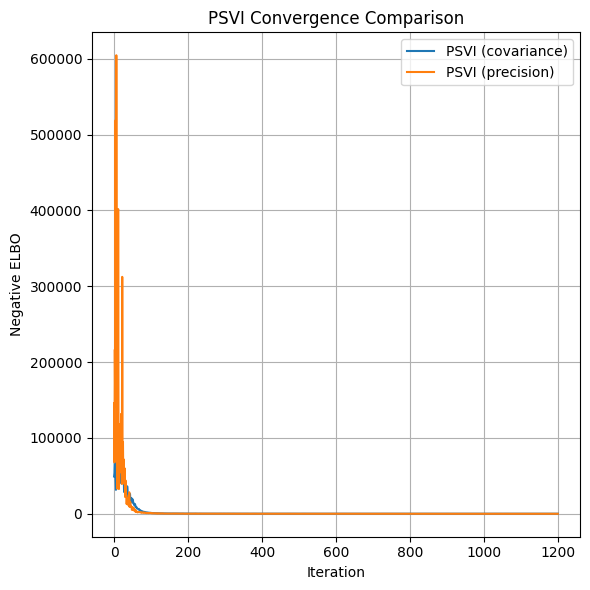

In [27]:
fig, ax = plt.subplots()
ax.plot(vi_losses, label="PSVI (covariance)")
ax.plot(vi_prec_losses, label="PSVI (precision)")
ax.set_xlabel("Iteration")
ax.set_ylabel("Negative ELBO")
ax.set_title("PSVI Convergence Comparison")
ax.legend()
ax.grid(True)
fig.tight_layout()

## Extract PSVI-Precision posterior samples

In [28]:
# Generate N samples from PSVI-Precision posterior
vi_prec_key, sample_key_prec = jax.random.split(vi_prec_key)
mu_post_prec = vi_prec_params["mu"]
Lambda_post = _build_precision(vi_prec_params)
chol_prec_post = jnp.linalg.cholesky(Lambda_post)

# Sample: solve L_Lambda.T @ z0 = eps, then log_alpha = mu + z0
eps_post_prec = jax.random.normal(sample_key_prec, shape=(N, d_param))
z0_post = jax.scipy.linalg.solve_triangular(
    chol_prec_post.T, eps_post_prec.T, lower=False
)
log_alpha_post_prec = mu_post_prec[:, None] + z0_post
A_PSVI_prec = np.array(jnp.clip(jnp.exp(log_alpha_post_prec), 1e-8, alpha_max))  # (d_param, N)

err_psvi_prec = alpha_t.ravel() - A_PSVI_prec.mean(axis=1)
rmse_psvi_prec = np.sqrt(np.mean(err_psvi_prec**2))
print(f"RMSE PSVI-Precision: {rmse_psvi_prec:.6f}")
print(f"RMSE PSVI-Covariance: {rmse_psvi:.6f}")

# Run forward model on PSVI-Precision posterior samples
alphas_psvi_prec = [A_PSVI_prec[:, j].reshape(nx, nx) for j in range(N)]
alphas_psvi_prec_jax = jnp.stack([jnp.array(a) for a in alphas_psvi_prec])
fwd_runs_psvi_prec_jax = batched_heat_equation(
    u0_jax, alphas_psvi_prec_jax, dx, dt, num_steps, keys, scale
)

Y_df_psvi_prec = pd.DataFrame({"k": k_levels, "x": x_levels, "y": y_levels})
for real in range(N):
    fwd_run = np.asarray(fwd_runs_psvi_prec_jax[real])
    Y_df_psvi_prec = Y_df_psvi_prec.assign(
        **{f"R{real}": fwd_run[k_levels, x_levels, y_levels]}
    )
Y_df_psvi_prec = Y_df_psvi_prec.set_index(["k", "x", "y"])

RMSE PSVI-Precision: 3.156120
RMSE PSVI-Covariance: 3.071260


/var/folders/qj/kll_f5_n7cl8w2l46ndtgws00000gp/T/ipykernel_80550/775418835.py:30: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  Y_df_psvi_prec = Y_df_psvi_prec.assign(


## ELBO decomposition diagnostic

The RMSE comparison only looks at posterior means. This diagnostic evaluates the final covariance- and precision-parameterized variational distributions with shared Monte Carlo noise and decomposes the negative ELBO into likelihood and KL terms.

In [29]:
n_eval_mc = 512
diag_key = jax.random.PRNGKey(20260709)
eps_eval = jax.random.normal(diag_key, shape=(n_eval_mc, d_param))


def _responses_from_log_alpha(log_alpha_samples):
    n_samples = log_alpha_samples.shape[0]
    alpha_samples = jnp.clip(jnp.exp(log_alpha_samples), 1e-8, alpha_max).reshape(
        n_samples, nx, nx
    )
    eval_keys = jax.random.split(jax.random.PRNGKey(20260710), n_samples)
    u_eval = jax.vmap(
        pde.heat_equation_jax,
        in_axes=(None, 0, None, None, None, 0, None),
    )(u0_jax, alpha_samples, dx, dt, num_steps, eval_keys, None)
    return u_eval[:, obs_k_vi, obs_x_vi, obs_y_vi]


def _likelihood_parts(responses):
    residuals = obs_val_vi[None, :] - responses
    weighted_sq_residual = jnp.mean(
        jnp.sum(residuals**2 / obs_var_vi[None, :], axis=1)
    )
    response_mean = jnp.mean(responses, axis=0)
    response_var = jnp.var(responses, axis=0)
    response_std = jnp.sqrt(response_var)

    mean_fit_penalty = jnp.sum((obs_val_vi - response_mean) ** 2 / obs_var_vi)
    spread_penalty = jnp.sum(response_var / obs_var_vi)
    log_lik_constant = jnp.sum(jnp.log(2.0 * jnp.pi * obs_var_vi))
    expected_log_lik = -0.5 * (weighted_sq_residual + log_lik_constant)

    return {
        "expected_log_lik": expected_log_lik,
        "weighted_sq_residual": weighted_sq_residual,
        "mean_fit_penalty": mean_fit_penalty,
        "spread_penalty": spread_penalty,
        "log_lik_constant": log_lik_constant,
        "response_std_min": response_std.min(),
        "response_std_mean": response_std.mean(),
        "response_std_max": response_std.max(),
    }


def _kl_parts(mu, Sigma_q, logdet_Sigma_q):
    param_std = jnp.sqrt(jnp.diag(Sigma_q))
    trace_term = jnp.sum(prior_prec * Sigma_q)
    mean_term = mu @ prior_prec @ mu
    dimension_term = -d_param
    q_logdet_term = -logdet_Sigma_q
    kl = 0.5 * (
        trace_term
        + mean_term
        + dimension_term
        + prior_logdet
        + q_logdet_term
    )

    return {
        "kl": kl,
        "trace_term": trace_term,
        "mean_term": mean_term,
        "dimension_term": dimension_term,
        "prior_logdet": prior_logdet,
        "q_logdet_term": q_logdet_term,
        "param_std_min": param_std.min(),
        "param_std_mean": param_std.mean(),
        "param_std_max": param_std.max(),
    }


def _combine_elbo_parts(likelihood, kl):
    return {
        **likelihood,
        **kl,
        "neg_elbo": -likelihood["expected_log_lik"] + kl["kl"],
    }


def _as_float_dict(parts):
    return {key: float(np.asarray(value)) for key, value in parts.items()}


# Covariance-parameterized q(m) = N(mu, L L.T)
mu_cov_eval = vi_params["mu"]
L_cov_eval = _build_L(vi_params)
Sigma_cov_eval = L_cov_eval @ L_cov_eval.T
logdet_Sigma_cov_eval = 2.0 * jnp.sum(
    jnp.log(jnp.maximum(jnp.diag(L_cov_eval), tri_diag_eps))
)
log_alpha_cov_eval = mu_cov_eval[None, :] + (L_cov_eval @ eps_eval.T).T
responses_cov_eval = _responses_from_log_alpha(log_alpha_cov_eval)
cov_parts = _combine_elbo_parts(
    _likelihood_parts(responses_cov_eval),
    _kl_parts(mu_cov_eval, Sigma_cov_eval, logdet_Sigma_cov_eval),
)

# Precision-parameterized q(m) = N(mu, Lambda^-1)
mu_prec_eval = vi_prec_params["mu"]
Lambda_prec_eval = _build_precision(vi_prec_params)
chol_prec_eval = jnp.linalg.cholesky(Lambda_prec_eval)
Sigma_prec_eval = jax.scipy.linalg.cho_solve(
    (chol_prec_eval, True), jnp.eye(d_param)
)
logdet_Lambda_prec_eval = 2.0 * jnp.sum(
    jnp.log(jnp.maximum(jnp.diag(chol_prec_eval), tri_diag_eps))
)
logdet_Sigma_prec_eval = -logdet_Lambda_prec_eval
z_prec_eval = jax.scipy.linalg.solve_triangular(
    chol_prec_eval.T, eps_eval.T, lower=False
)
log_alpha_prec_eval = (mu_prec_eval[:, None] + z_prec_eval).T
responses_prec_eval = _responses_from_log_alpha(log_alpha_prec_eval)
prec_parts = _combine_elbo_parts(
    _likelihood_parts(responses_prec_eval),
    _kl_parts(mu_prec_eval, Sigma_prec_eval, logdet_Sigma_prec_eval),
)

diagnostic_rows = [
    "neg_elbo",
    "expected_log_lik",
    "kl",
    "weighted_sq_residual",
    "mean_fit_penalty",
    "spread_penalty",
    "log_lik_constant",
    "trace_term",
    "mean_term",
    "q_logdet_term",
    "param_std_min",
    "param_std_mean",
    "param_std_max",
    "response_std_min",
    "response_std_mean",
    "response_std_max",
]

elbo_diagnostics = pd.DataFrame(
    {
        "PSVI (covariance)": _as_float_dict(cov_parts),
        "PSVI (precision)": _as_float_dict(prec_parts),
    }
).loc[diagnostic_rows]

print(f"ELBO diagnostics estimated with n_eval_mc={n_eval_mc} samples")
display(elbo_diagnostics)

ELBO diagnostics estimated with n_eval_mc=512 samples


,PSVI (covariance),PSVI (precision)
neg_elbo,81.017481,12.893500
expected_log_lik,47.893475,21.591026
kl,128.910955,34.484527
weighted_sq_residual,61.735850,114.340747
mean_fit_penalty,60.868704,63.443434
spread_penalty,0.867147,50.897312
log_lik_constant,-157.522800,-157.522800
trace_term,116.450792,87.955353
mean_term,33.782266,40.206374
q_logdet_term,982.792076,816.010550


## Posterior-covariance evaluation: does the sparse precision capture correlations?

The RMSE tables above only score the posterior *mean*. The whole motivation for the
sparse-precision parameterisation is the posterior *covariance* - specifically its ability to
represent long-range spatial correlations using only local (neighbour) precision terms. To
measure that, we compare each variational posterior against a reference posterior.

**Reference (Gauss-Newton / Laplace).** Because the forward model $g(\mathbf{m})$ is
differentiable, we linearise it at the MAP point $\mathbf{m}^*$ and form the linear-Gaussian
posterior precision

$$\Lambda_\mathrm{ref} = C_M^{-1} + J^\top R^{-1} J, \qquad J = \left.\frac{\partial g}{\partial \mathbf{m}}\right|_{\mathbf{m}^*},$$

which is *exactly* the structure the prior-anchored precision method is built to mirror.

> **Caveat.** The Laplace reference is exact only for a linear-Gaussian model. Here
> $g(\mathbf{m})$ is nonlinear in $\mathbf{m}$ (through $\exp(\cdot)$ and the PDE), so treat
> $\Lambda_\mathrm{ref}$ as a strong *local* reference for the posterior correlation structure,
> not as ground truth. A non-linearised gold standard would require MCMC.

We report, for the prior and both variational posteriors: Frobenius error of the correlation
matrix, relative covariance error, the Gaussian KL both ways, marginal-variance calibration,
and how well the posterior precision aligns with the reference on the modelled neighbour pattern.

In [30]:
# Gauss-Newton / Laplace reference posterior.
# The prior-anchored precision method is built to mirror the linear-Gaussian posterior
# precision  Lambda = C_M^-1 + J^T R^-1 J.  Since g(m) is differentiable we can build
# that reference almost for free and use it to score correlation capture.


def forward_obs(m):
    # g(m): log-conductivity vector -> responses at sensors.
    # Same clip/exp/reshape as the ELBOs so the Jacobian J matches g.
    alpha = jnp.clip(jnp.exp(m), 1e-8, alpha_max).reshape(nx, nx)
    u = pde.heat_equation_jax(u0_jax, alpha, dx, dt, num_steps)
    return u[obs_k_vi, obs_x_vi, obs_y_vi]


def neg_log_post(m):
    # Unnormalised negative log-posterior: Gaussian likelihood + Gaussian prior.
    resid = obs_val_vi - forward_obs(m)
    return 0.5 * jnp.sum(resid**2 / obs_var_vi) + 0.5 * (m @ prior_prec @ m)


# MAP estimate = linearisation point for the Laplace approximation.
map_optimizer = optax.adam(learning_rate=0.05)
m_map = jnp.zeros(d_param)
map_state = map_optimizer.init(m_map)


@jax.jit
def map_step(m, state):
    loss, grad = jax.value_and_grad(neg_log_post)(m)
    updates, state = map_optimizer.update(grad, state)
    return optax.apply_updates(m, updates), state, loss


map_losses = []
for _ in range(1500):
    m_map, map_state, map_loss = map_step(m_map, map_state)
    map_losses.append(float(map_loss))
print(f"MAP neg-log-posterior: {map_losses[0]:.2f} -> {map_losses[-1]:.2f}")

# The explicit-scheme stability clip must be inactive at the MAP, else J has zero rows.
alpha_map_max = float(jnp.exp(m_map).max())
print(f"max alpha(MAP) = {alpha_map_max:.4f}  (alpha_max = {alpha_max:.4f})")
if alpha_map_max >= alpha_max:
    print("WARNING: MAP hit the stability clip; Laplace Jacobian may be degenerate.")

# Gauss-Newton / Laplace posterior.
J_ref = jax.jacrev(forward_obs)(m_map)  # (n_obs, d_param)
Lambda_ref = prior_prec + (J_ref / obs_var_vi[:, None]).T @ J_ref
chol_ref = jnp.linalg.cholesky(Lambda_ref)
Sigma_ref = jax.scipy.linalg.cho_solve((chol_ref, True), jnp.eye(d_param))
mu_ref = m_map
prior_cov_j = jnp.asarray(prior_cov)

print(f"Lambda_ref min eig: {float(jnp.linalg.eigvalsh(Lambda_ref).min()):.3e}  (PD if > 0)")
print(
    "max(diag Sigma_ref / diag C_M): "
    f"{float((jnp.diag(Sigma_ref) / jnp.diag(prior_cov_j)).max()):.3f}  (<= 1 since data adds info)"
)

MAP neg-log-posterior: 45791.31 -> 41.51
max alpha(MAP) = 8.2676  (alpha_max = 21.9476)


Lambda_ref min eig: 2.942e-01  (PD if > 0)
max(diag Sigma_ref / diag C_M): 0.671  (<= 1 since data adds info)


In [31]:
# Covariance-quality metrics vs the Laplace reference.
def corr_from_cov(S):
    s = jnp.sqrt(jnp.diag(S))
    return S / jnp.outer(s, s)


def gauss_kl(mu0, S0, mu1, S1):
    # KL( N(mu0, S0) || N(mu1, S1) ) in nats, closed form.
    c1 = jnp.linalg.cholesky(S1)
    diff = mu1 - mu0
    trace_term = jnp.trace(jax.scipy.linalg.cho_solve((c1, True), S0))
    quad_term = diff @ jax.scipy.linalg.cho_solve((c1, True), diff)
    logdet_S1 = 2.0 * jnp.sum(jnp.log(jnp.diag(c1)))
    logdet_S0 = jnp.linalg.slogdet(S0)[1]
    return 0.5 * (trace_term + quad_term - mu0.shape[0] + logdet_S1 - logdet_S0)


def moments_cov(params):
    mu = params["mu"]
    L = _build_L(params)
    S = L @ L.T
    return mu, S, jnp.linalg.inv(S)


def moments_prec(params):
    mu = params["mu"]
    Lam = _build_precision(params)
    S = jax.scipy.linalg.cho_solve((jnp.linalg.cholesky(Lam), True), jnp.eye(d_param))
    return mu, S, Lam


methods = {
    "Prior": (jnp.zeros(d_param), prior_cov_j, prior_prec),
    "PSVI (covariance)": moments_cov(vi_params),
    "PSVI (precision)": moments_prec(vi_prec_params),
}

# Grid-neighbour off-diagonal pattern, for data-induced precision-structure recovery.
offdiag_pattern = np.zeros((d_param, d_param), dtype=bool)
for b in [1, nx - 1, nx, nx + 1]:
    mask_b = np.asarray(band_masks[b])
    idx = np.arange(d_param - b)[mask_b]
    offdiag_pattern[idx + b, idx] = True
    offdiag_pattern[idx, idx + b] = True

corr_ref = corr_from_cov(Sigma_ref)
ref_fro = float(jnp.linalg.norm(Sigma_ref))

# Data-induced precision of the reference:  J^T R^-1 J = Lambda_ref - C_M^-1.
# This is the part the sparse Delta_Lambda must capture (C_M^-1 is anchored exactly),
# so alignment on it - not on the C_M^-1-dominated full precision - is the honest test.
dref = np.asarray(Lambda_ref - prior_prec)
dref_off = dref - np.diag(np.diag(dref))
off_frac_outside = 1.0 - (dref_off[offdiag_pattern] ** 2).sum() / (dref_off**2).sum()
dref_pat = dref[offdiag_pattern]
print(
    "Data-induced precision (J^T R^-1 J) off-diagonal energy OUTSIDE the neighbour pattern: "
    f"{off_frac_outside:.3f}  (0 => fully captured by the modelled neighbours)"
)

rows = {}
for name, (mu, S, Lam) in methods.items():
    dpat = np.asarray(Lam - prior_prec)[offdiag_pattern]  # learned precision update on the pattern
    rows[name] = {
        "corr_err_fro": float(jnp.linalg.norm(corr_from_cov(S) - corr_ref)),
        "cov_relerr": float(jnp.linalg.norm(S - Sigma_ref) / ref_fro),
        "KL(q||ref)": float(gauss_kl(mu, S, mu_ref, Sigma_ref)),
        "KL(ref||q)": float(gauss_kl(mu_ref, Sigma_ref, mu, S)),
        "mean_err": float(jnp.linalg.norm(mu - mu_ref)),
        "std_ratio": float(jnp.mean(jnp.sqrt(jnp.diag(S)) / jnp.sqrt(jnp.diag(Sigma_ref)))),
        "dLam_nbr_cos": float(
            dpat @ dref_pat / (np.linalg.norm(dpat) * np.linalg.norm(dref_pat) + 1e-30)
        ),
    }

cov_eval = pd.DataFrame(rows).T[
    ["corr_err_fro", "cov_relerr", "KL(q||ref)", "KL(ref||q)", "mean_err", "std_ratio", "dLam_nbr_cos"]
]
print(
    "\ncorr_err_fro/cov_relerr/KL: lower=better; std_ratio ~1 = calibrated; "
    "dLam_nbr_cos ~1 = recovers the data-induced precision structure"
)
display(cov_eval)

Data-induced precision (J^T R^-1 J) off-diagonal energy OUTSIDE the neighbour pattern: 0.084  (0 => fully captured by the modelled neighbours)



corr_err_fro/cov_relerr/KL: lower=better; std_ratio ~1 = calibrated; dLam_nbr_cos ~1 = recovers the data-induced precision structure


,corr_err_fro,cov_relerr,KL(q||ref),KL(ref||q),mean_err,std_ratio,dLam_nbr_cos
Prior,40.711181,8.636570,27621.291828,30.747418,7.738795,7.167558,0.000000
PSVI (covariance),24.156774,0.998582,96.258880,23260.990332,2.517841,0.063124,-0.038447
PSVI (precision),14.769381,0.541126,25.547031,13.973009,1.899063,0.862520,0.706262


### Correlation maps

For an anchor cell, the panels below show its posterior correlation with every other grid cell.
A banded-covariance $q$ can only produce short-range correlation; a sparse-*precision* $q$ can
reproduce the smooth long-range halo of the reference posterior.

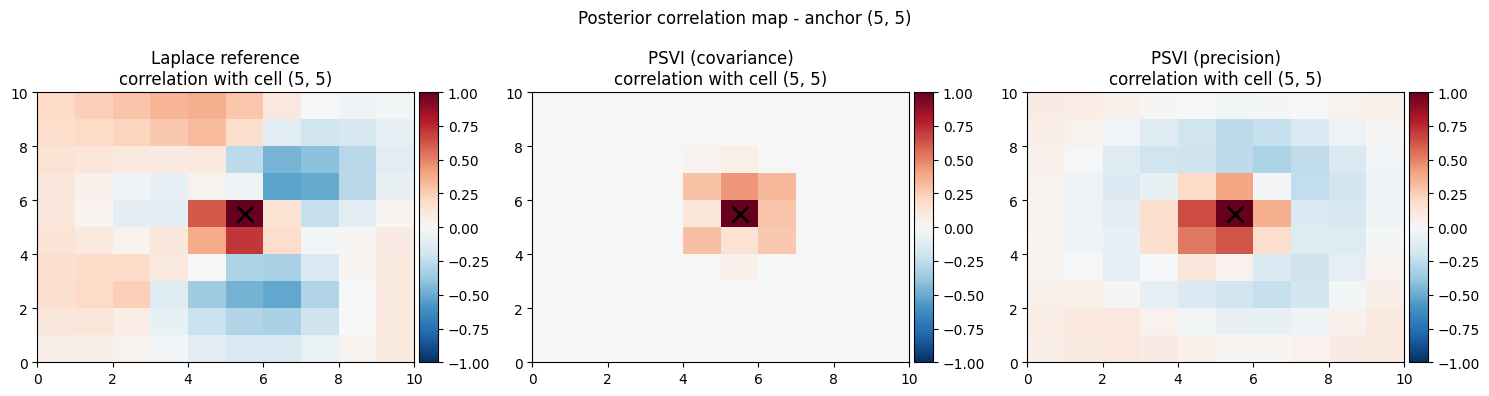

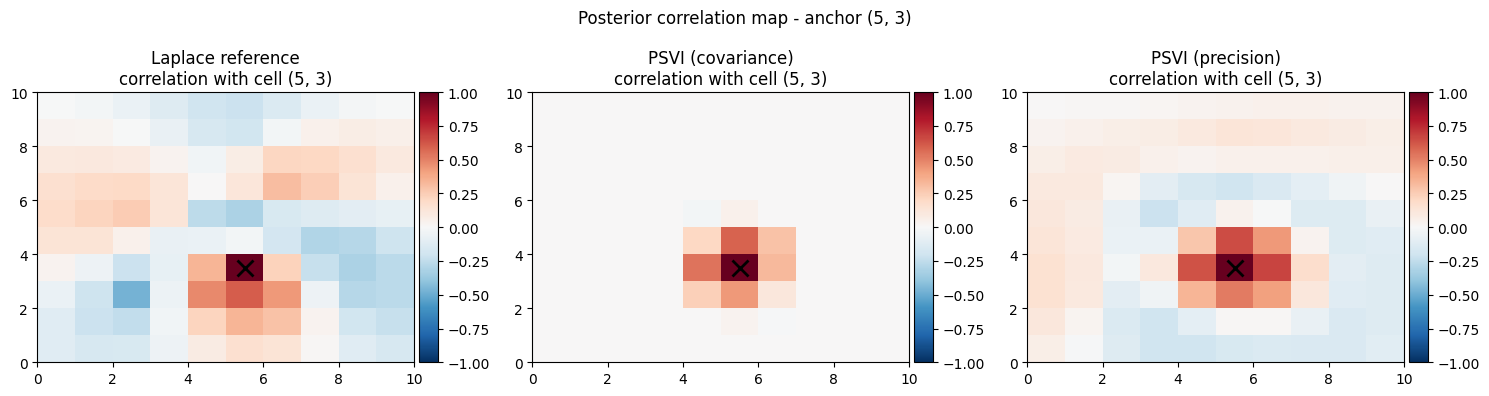

In [32]:
# Correlation maps: how far in space does each posterior spread correlation?
anchor_cells = [(5, 5), (5, 3)]  # a central cell and a sensor location

for (ar, ac) in anchor_cells:
    a = ar * nx + ac
    fig, axes = plt.subplots(1, 3, figsize=(15, 4))
    panels = [
        ("Laplace reference", Sigma_ref),
        ("PSVI (covariance)", methods["PSVI (covariance)"][1]),
        ("PSVI (precision)", methods["PSVI (precision)"][1]),
    ]
    for ax, (title, S) in zip(axes, panels):
        cmap_img = np.asarray(corr_from_cov(S)[a]).reshape(nx, nx)
        p = ax.pcolormesh(cmap_img.T, cmap="RdBu_r", vmin=-1, vmax=1)
        ax.plot(ar + 0.5, ac + 0.5, "kx", markersize=12, markeredgewidth=2)
        ax.set_title(f"{title}\ncorrelation with cell {(ar, ac)}")
        utils.colorbar(p)
    fig.suptitle(f"Posterior correlation map - anchor {(ar, ac)}")
    fig.tight_layout()

## Comparison: ES vs PSVI (covariance) vs PSVI (precision)

In [33]:
rmse_prior = np.sqrt(np.mean((alpha_t.ravel() - A.mean(axis=1)) ** 2))
rmse_es = np.sqrt(np.mean((alpha_t.ravel() - A_ES.mean(axis=1)) ** 2))

print("Parameter-space RMSE (posterior mean vs truth):")
print(f"  Prior:              {rmse_prior:.6f}")
print(f"  ES:                 {rmse_es:.6f}")
print(f"  PSVI (covariance):  {rmse_psvi:.6f}")
print(f"  PSVI (precision):   {rmse_psvi_prec:.6f}")

# Data-space RMSE: how well do posterior mean parameters predict observations?
obs_idx = d_filtered.index
obs_k = obs_idx.get_level_values("k").to_list()
obs_x = obs_idx.get_level_values("x").to_list()
obs_y = obs_idx.get_level_values("y").to_list()
obs_vals = d_filtered["value"].values

def data_rmse(alpha_field):
    u_pred = np.asarray(pde.heat_equation_jax(u0_jax, jnp.array(alpha_field), dx, dt, num_steps))
    return np.sqrt(np.mean((obs_vals - u_pred[obs_k, obs_x, obs_y]) ** 2))

print("\nData-space RMSE (predicted vs observed at sensor locations):")
print(f"  Prior mean:         {data_rmse(A.mean(axis=1).reshape(nx, nx)):.6f}")
print(f"  ES:                 {data_rmse(A_ES.mean(axis=1).reshape(nx, nx)):.6f}")
print(f"  PSVI (covariance):  {data_rmse(A_PSVI.mean(axis=1).reshape(nx, nx)):.6f}")
print(f"  PSVI (precision):   {data_rmse(A_PSVI_prec.mean(axis=1).reshape(nx, nx)):.6f}")
print(f"  Truth:              {data_rmse(alpha_t):.6f}")

Parameter-space RMSE (posterior mean vs truth):
  Prior:              3.826766
  ES:                 1.896370
  PSVI (covariance):  3.071260
  PSVI (precision):   3.156120

Data-space RMSE (predicted vs observed at sensor locations):
  Prior mean:         3.491195
  ES:                 0.733440
  PSVI (covariance):  0.229226
  PSVI (precision):   0.259211


  Truth:              0.283672


## Side-by-side comparison of ES, PSVI (covariance) and PSVI (precision) history match

/var/folders/qj/kll_f5_n7cl8w2l46ndtgws00000gp/T/ipykernel_80550/3651698371.py:9: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  Y_df_post = Y_df_post.assign(**{f"R{real}": fwd_run[k_levels, x_levels, y_levels]})


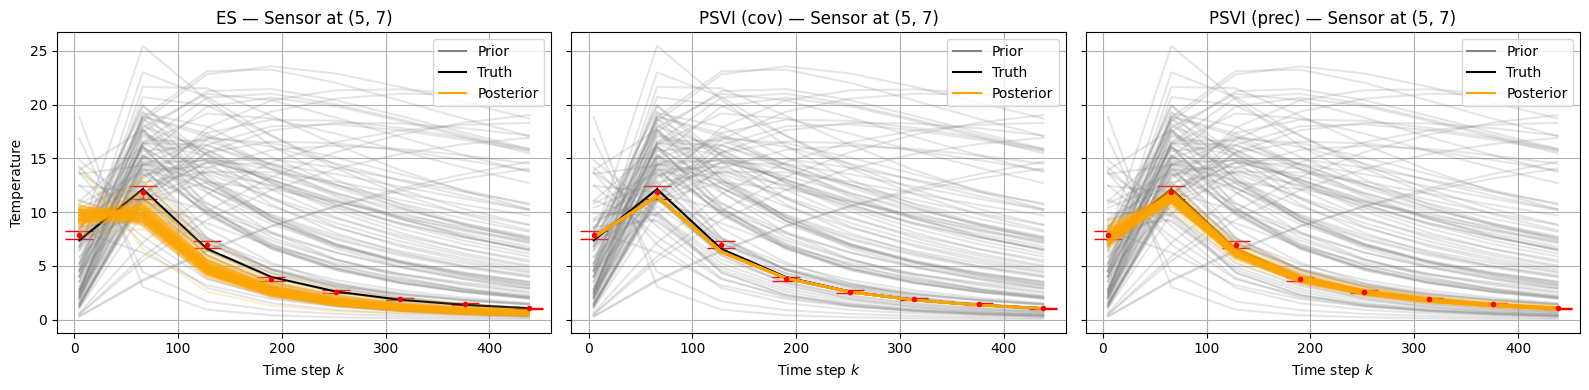

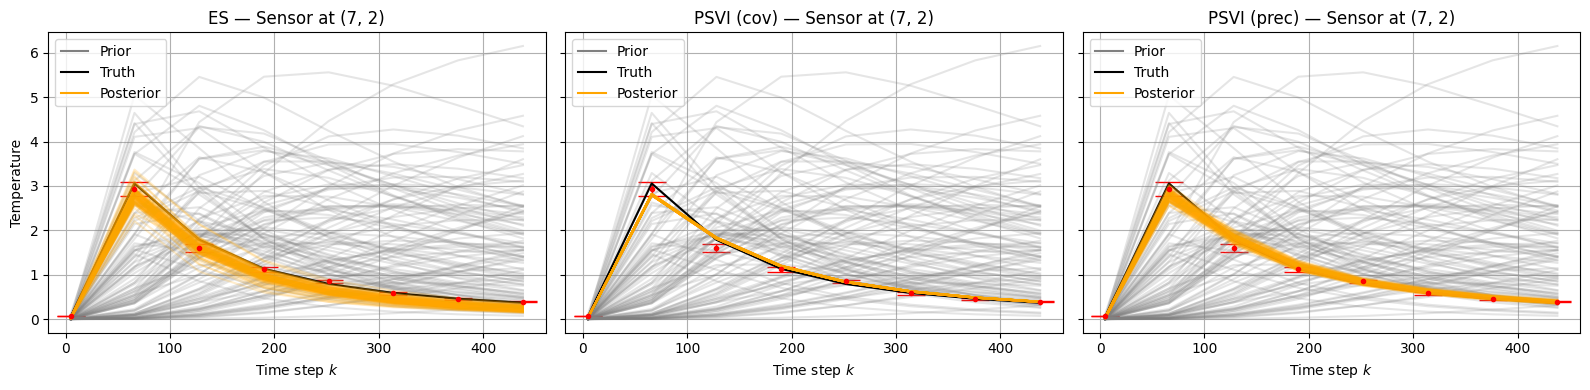

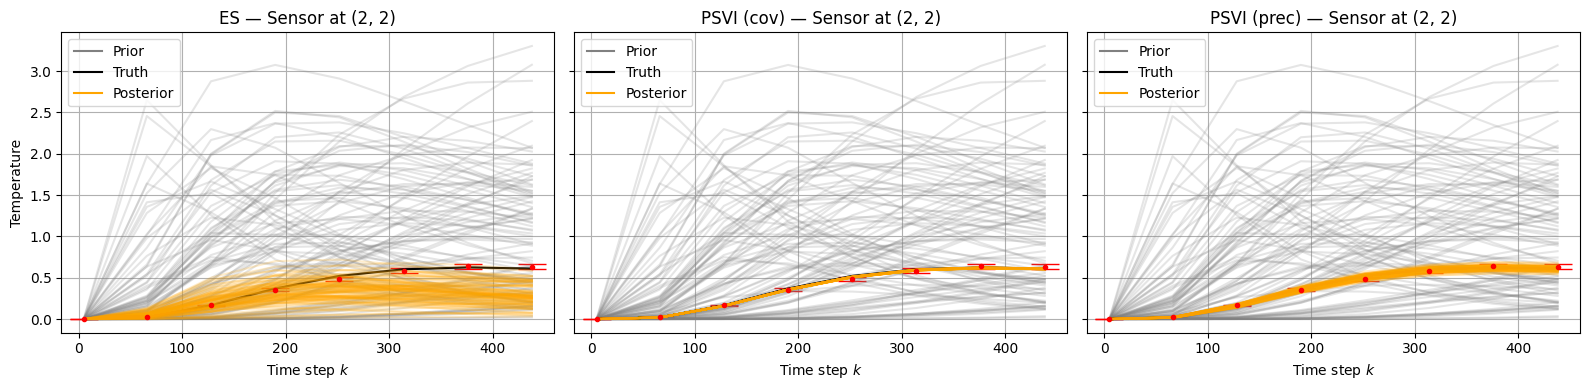

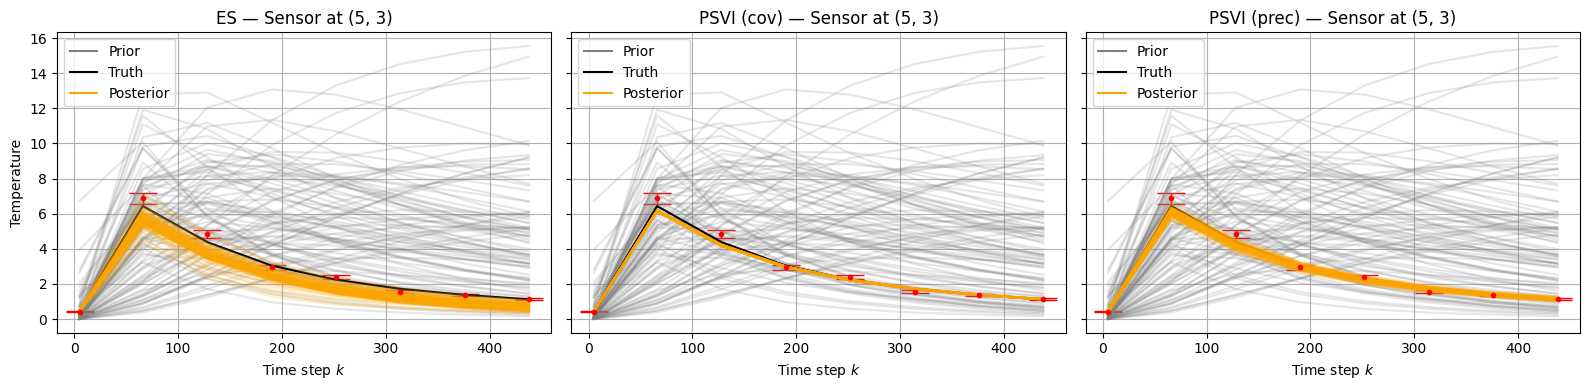

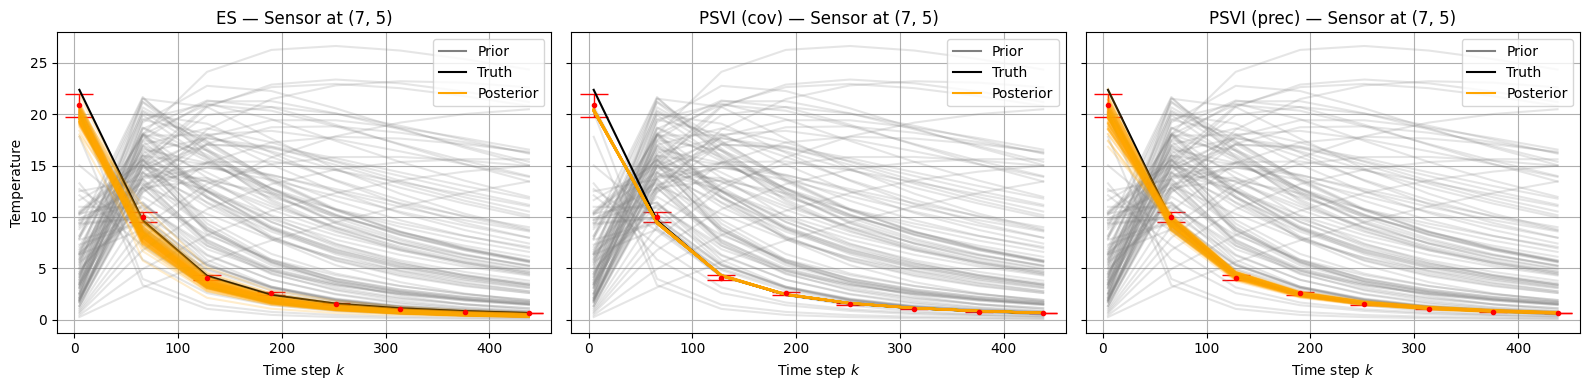

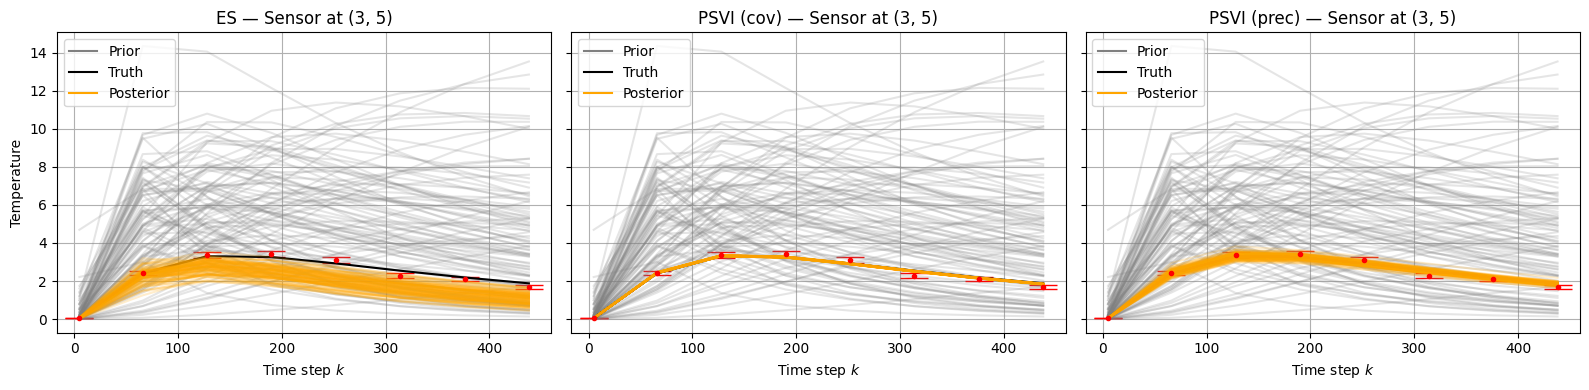

In [34]:
# Compute ES posterior responses (needed for side-by-side comparison)
alphas_post = [A_ES[:, j].reshape(nx, nx) for j in range(N)]
alphas_post_jax = jnp.stack([jnp.array(a) for a in alphas_post])
fwd_runs_post_jax = batched_heat_equation(u0_jax, alphas_post_jax, dx, dt, num_steps, keys, scale)

Y_df_post = pd.DataFrame({"k": k_levels, "x": x_levels, "y": y_levels})
for real in range(N):
    fwd_run = np.asarray(fwd_runs_post_jax[real])
    Y_df_post = Y_df_post.assign(**{f"R{real}": fwd_run[k_levels, x_levels, y_levels]})
Y_df_post = Y_df_post.set_index(["k", "x", "y"])

time_steps = np.unique(k_levels)

for x, y in obs_coordinates_from_index:
    fig, axes = plt.subplots(nrows=1, ncols=3, figsize=(16, 4), sharey=True)

    df_single_sensor = d.query(f"x=={x} & y=={y}")
    y_sensor = df_single_sensor["value"]
    yerr_sensor = df_single_sensor["sd"]

    for ax, post_df, method in zip(
        axes,
        [Y_df_post, Y_df_psvi, Y_df_psvi_prec],
        ["ES", "PSVI (cov)", "PSVI (prec)"],
    ):
        ax.set_title(f"{method} — Sensor at ({x}, {y})")
        ax.set_xlabel("Time step $k$")
        ax.grid()

        ax.errorbar(
            time_steps, y_sensor, yerr_sensor,
            ecolor="red", fmt="o", color="red", markersize=3, capsize=10, elinewidth=1, markeredgewidth=1,
        )

        ax.plot(time_steps, Y_df.query(f"x=={x} & y=={y}"),
                color="gray", alpha=0.2, label="_nolegend_")
        ax.plot([], [], "gray", label="Prior")

        ax.plot(time_steps, u_t[time_steps, x, y], color="black", label="Truth")

        ax.plot(time_steps, post_df.query(f"x=={x} & y=={y}"),
                color="orange", alpha=0.2, label="_nolegend_")
        ax.plot([], [], "orange", label="Posterior")

        ax.legend(loc="best")

    axes[0].set_ylabel("Temperature")
    fig.tight_layout()